In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Advanced Analytics Started")

Advanced Analytics Started


In [2]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

print("Performance Shape:", performance.shape)
print("Transactions Shape:", transactions.shape)

Performance Shape: (40, 19)
Transactions Shape: (32778, 13)


In [3]:
returns = performance["return_1yr_pct"]

var_95 = np.percentile(returns, 5)

print("95% Value at Risk (VaR):", round(var_95,2), "%")

95% Value at Risk (VaR): 6.14 %


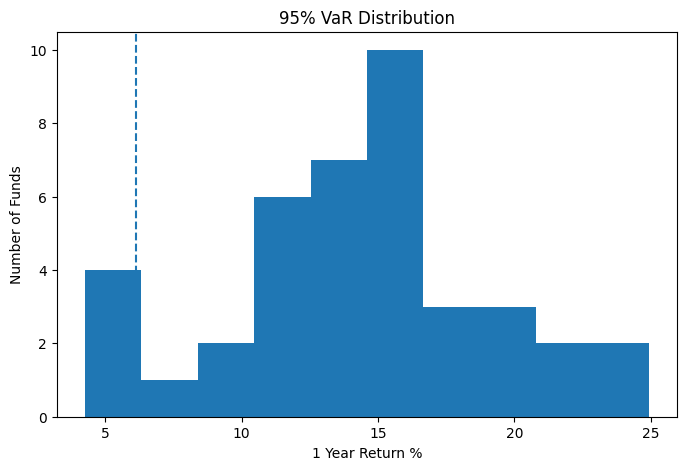

In [4]:
plt.figure(figsize=(8,5))

plt.hist(
    returns,
    bins=10
)

plt.axvline(
    var_95,
    linestyle="--"
)

plt.title("95% VaR Distribution")
plt.xlabel("1 Year Return %")
plt.ylabel("Number of Funds")

plt.show()

In [5]:
cohort = (
    transactions
    .groupby("age_group")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

cohort

age_group
26-35    1451600218
36-45     871647528
18-25     531639392
46-55     405406469
56+       261286823
Name: amount_inr, dtype: int64

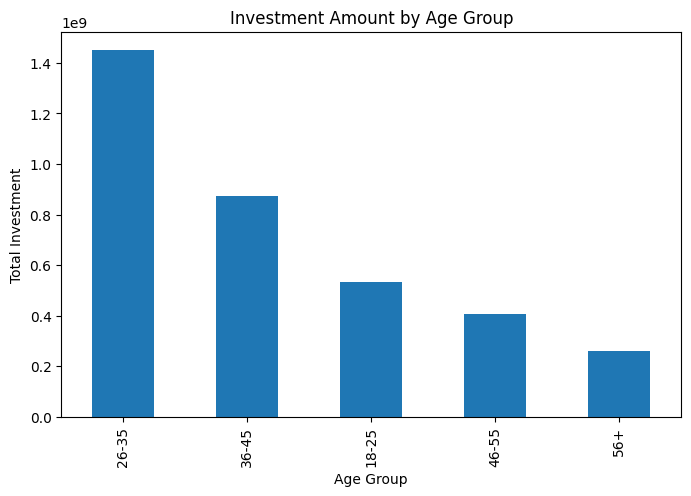

In [6]:
plt.figure(figsize=(8,5))

cohort.plot(kind="bar")

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Investment")

plt.show()

In [7]:
recommended = (
    performance
    .sort_values(
        by="sharpe_ratio",
        ascending=False
    )
)

recommended[
    [
        "scheme_name",
        "sharpe_ratio",
        "return_3yr_pct",
        "risk_grade"
    ]
].head(10)

,scheme_name,sharpe_ratio,return_3yr_pct,risk_grade
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,7.68,Low
23,Kotak Liquid Fund - Regular - Growth,6.18,6.18,Low
30,ABSL Liquid Fund - Regular - Growth,5.14,5.14,Low
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,7.37,Low
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,6.07,Low
19,Nippon India Gilt Securities Fund - Regular - ...,1.33,5.31,Low
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,14.81,Moderate
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,14.84,Moderate
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,14.41,Moderate
15,Nippon India Large Cap Fund - Regular - Growth,1.00,14.00,Moderate


In [8]:
top5 = recommended.head(5)

top5.to_csv(
    "../data/processed/recommended_funds.csv",
    index=False
)

top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [9]:
# Advanced Analytics Findings

## Value at Risk (VaR)
#- Calculated 95% VaR using historical fund returns.
#- Identified downside risk threshold.

## Cohort Analysis
#- Compared investment behaviour across age groups.
#- Determined highest contributing investor segment.

## Fund Recommender
#- Ranked funds using Sharpe Ratio.
#- Recommended top-performing risk-adjusted funds.